# **Preliminary Checks**

In [21]:

# Others 
import numpy as np
import matplotlib.pyplot as plt
# import pyvista 

# Plasma Equilibrium 
from simsopt.mhd import Vmec 
from simsopt.mhd.profiles import ProfilePolynomial, ProfileSpline, ProfilePressure, ProfileScaled
from simsopt.util.constants import ELEMENTARY_CHARGE
import vmecpp 
import vmec 

# Coil Optimisation 
from coilpy import * 

# Heat Transport 
import flare
from flare import tasks
import firefly


In [2]:
import sys
# Double check the path just to be safe
print([p for p in sys.path if 'flare' in p])

[]


### Checking each Modules Capabilities 

In [23]:
import importlib
import pkgutil
import inspect

package = flare
print(f"Modules in package '{package.__name__}':")

# Walk through and print all sub-modules
for module_info in pkgutil.iter_modules(package.__path__):
    print(f" - {module_info.name}")


print(f"Classes inside the mmesh module:")
# Get members and filter for classes
for name, obj in inspect.getmembers(flare.mmesh, inspect.isclass):
    print(f" - Class Name: {name} | Object: {obj}")



# Print all routines (methods/functions) belonging to the class
print("Methods in Mmesh Class:")
for name, data in inspect.getmembers(flare.mmesh.Mmesh, inspect.isroutine):
    print(f" - {name}")
print("Methods in Qmesh Class:")
for name, data in inspect.getmembers(flare.mmesh.Qmesh, inspect.isroutine):
    print(f" - {name}")
print("Methods in Torosurf Class:")
for name, data in inspect.getmembers(flare.mmesh.Torosurf, inspect.isroutine):
    print(f" - {name}")

Modules in package 'flare':
 - _f2py
 - analysis
 - bfield
 - cli
 - control
 - f2py
 - mmesh
 - model
 - tasks
 - utils
Classes inside the mmesh module:
 - Class Name: Mmesh | Object: <class 'flare.mmesh.mmesh.Mmesh'>
 - Class Name: Qmesh | Object: <class 'moose.grids.qmesh.Qmesh'>
 - Class Name: Torosurf | Object: <class 'moose.geometry.surfaces.torosurf.Torosurf'>
Methods in Mmesh Class:
 - __delattr__
 - __dir__
 - __eq__
 - __format__
 - __ge__
 - __getattribute__
 - __getstate__
 - __gt__
 - __init__
 - __init_subclass__
 - __le__
 - __lt__
 - __ne__
 - __new__
 - __reduce__
 - __reduce_ex__
 - __repr__
 - __setattr__
 - __sizeof__
 - __str__
 - __subclasshook__
 - _axes
 - _axes_and_coordinates
 - _axes_order
 - _coordinates
 - _encoded_type
 - _ncattrs
 - _parsed_metadata
 - _plot_cells_data
 - _plot_nodes_data
 - _read
 - _readtxt
 - _readtxt_header
 - _readtxt_metadata
 - _rzslice
 - _shape
 - _size
 - _verify_type
 - _view
 - _writenc_axes
 - _writetxt
 - dtype
 - loadnc
 - 

In [28]:
import importlib
import pkgutil
import inspect
from firefly import tasks, geometry, objectives
package = firefly
print(f"Modules in package '{package.__name__}':")

# Walk through and print all sub-modules
for module_info in pkgutil.iter_modules(package.__path__):
    print(f" - {module_info.name}")


print(f"Classes inside the geometry module:")
# Get members and filter for classes
for name, obj in inspect.getmembers(firefly.geometry, inspect.isclass):
    print(f" - Class Name: {name} | Object: {obj}")

print(f"Classes inside the tasks module:")
# Get members and filter for classes
for name, obj in inspect.getmembers(firefly.tasks, inspect.isclass):
    print(f" - Class Name: {name} | Object: {obj}")

print(f"Classes inside the objectives module:")
# Get members and filter for classes
for name, obj in inspect.getmembers(firefly.objectives, inspect.isclass):
    print(f" - Class Name: {name} | Object: {obj}")


# Print all routines (methods/functions) belonging to the class
print("Methods in Geometry Class:")
for name, data in inspect.getmembers(firefly.geometry.Mmesh, inspect.isroutine):
    print(f" - {name}")
# print("Methods in Qmesh Class:")
# for name, data in inspect.getmembers(flare.mmesh.Qmesh, inspect.isroutine):
#     print(f" - {name}")
# print("Methods in Torosurf Class:")
# for name, data in inspect.getmembers(flare.mmesh.Torosurf, inspect.isroutine):
#     print(f" - {name}")

Modules in package 'firefly':
 - cli
 - f2py
 - geometry
 - objectives
 - pso
 - tasks
Classes inside the geometry module:
 - Class Name: Axisurf | Object: <class 'moose.geometry.surfaces.axisurf.Axisurf'>
 - Class Name: BoundaryGenerator | Object: <class 'firefly.geometry._boundary_generator.BoundaryGenerator'>
 - Class Name: Hypersurf3d | Object: <class 'moose.geometry.hypersurface.Hypersurf3d'>
 - Class Name: Mmesh | Object: <class 'flare.mmesh.unstructured.Mmesh'>
 - Class Name: PlateGenerator | Object: <class 'firefly.geometry.plategen.PlateGenerator'>
 - Class Name: Torosurf | Object: <class 'moose.geometry.surfaces.torosurf.Torosurf'>
 - Class Name: ValphaGenerator | Object: <class 'firefly.geometry.valpha.ValphaGenerator'>
 - Class Name: VcasingGenerator | Object: <class 'firefly.geometry.vcasing.VcasingGenerator'>
Classes inside the tasks module:
 - Class Name: Path | Object: <class 'pathlib.Path'>
Classes inside the objectives module:
 - Class Name: HeatLoadProxy | Object: <c

# **Heat Transport**

## **Converting Files**

In [ ]:
def convert_makegrid_to_flare(input_file, output_file):
    with open(input_file, 'r') as f:
        lines = f.readlines()

    nfp = 1                              # will be overwritten by 'periods' line
    coils = []
    current_coil_points = []
    current_val = None

    for line in lines:
        parts = line.split()
        if not parts:
            continue
        # if parts[0].lower() == 'periods':
        #     nfp = int(parts[1])
            continue
        if parts[0].lower() in ['begin', 'mirror', 'end']:
            continue

        if len(parts) >= 4:
            try:
                x, y, z, i = float(parts[0]), float(parts[1]), float(parts[2]), float(parts[3])
            except ValueError:
                continue

            if i != 0.0:
                current_coil_points.append((x, y, z))
                current_val = i
            else:
                current_coil_points.append((x, y, z))
                assert current_val is not None, "Coil ended without any non-zero current line"
                coils.append({
                    'points': current_coil_points,
                    'current': current_val
                })
                current_coil_points = []
                current_val = None

    # Write FLARE coilset format
    with open(output_file, 'w') as f:
        f.write("# HSX Coilset Converted from MAKEGRID format\n")
        f.write(f"{len(coils)}\n")

        for coil in coils:
            m = len(coil['points']) - 1
            I = coil['current']
            f.write(f"    {m}    {I:.15e}    {nfp}\n")   # ← changed 1 to nfp here
            for pt in coil['points']:
                f.write(f"        {pt[0]:.15e}  {pt[1]:.15e}  {pt[2]:.15e}\n")

    print(f"Converted {len(coils)} coils (nfp={nfp}, symmetry={nfp} per coil) -> {output_file}")

def convert_nescin_to_flare(input_file, output_file, ntheta=None, nzeta=None, oversample=3):
    surf = FourSurf.read_winding_surfce(input_file)

    with open(input_file, 'r') as f:
        line = ''
        while 'phip_edge' not in line:
            line = f.readline()
        nfp = int(f.readline().split()[0]) # Acquire the Number of Field Periods 

    M_max = int(np.max(np.abs(surf.xm))) # Number of 
    N_max = int(np.max(np.abs(surf.xn)) / nfp)

    if ntheta is None:
        ntheta = oversample * (2 * M_max + 1)
    if nzeta is None:
        nzeta  = oversample * (2 * N_max + 1)

    print(f"M_max={M_max}, N_max={N_max} -> ntheta={ntheta}, nzeta={nzeta}")

    theta = np.linspace(0, 2 * np.pi,       ntheta, endpoint=True)
    zeta  = np.linspace(0, 2 * np.pi / nfp, nzeta,  endpoint=True)

    tv, zv = np.meshgrid(theta, zeta, indexing="ij")
    R_flat, Z_flat = surf.rz(tv.ravel(), zv.ravel())
    R = R_flat.reshape((ntheta, nzeta))
    Z = Z_flat.reshape((ntheta, nzeta))

    with open(output_file, 'w') as f:
        f.write("HSX PFC Boundary offset from LCFS via NESCOIL\n")
        f.write(f"  {nzeta}   {ntheta}   {nfp}\n")
        for i in range(nzeta):
            phi_deg = zeta[i] * 180.0 / np.pi
            f.write(f"  {phi_deg:.6f}\n")
            for j in range(ntheta):
                f.write(f"    {R[j, i]:.8f}    {Z[j, i]:.8f}\n")

    print(f"Written: {output_file} (nfp={nfp}, ntheta={ntheta}, nzeta={nzeta})")


In [8]:
# Run the function
input_path = "/home/yuanl/Academia/Projects/Internship_USTC/Data/FLARE_DB/HSX_Test/shared_data/coils.hsx"
output_path = "/home/yuanl/Academia/Projects/Internship_USTC/Data/FLARE_DB/HSX_Test/shared_data/HSX_coilset"
convert_makegrid_to_flare(input_path, output_path)

Converted 48 coils (nfp=1, symmetry=1 per coil) -> /home/yuanl/Academia/Projects/Internship_USTC/Data/FLARE_DB/HSX_Test/shared_data/HSX_coilset


In [9]:
# Define your absolute directories
input_path1 = "/home/yuanl/Academia/Projects/Internship_USTC/Data/Test/nescin_sep_0.05"
input_path2 = "/home/yuanl/Academia/Projects/Internship_USTC/Data/Test/nescin_sep_0.10"
input_path3 = "/home/yuanl/Academia/Projects/Internship_USTC/Data/Test/nescin_sep_0.15"
output_path1 = "/home/yuanl/Academia/Projects/Internship_USTC/Data/FLARE_DB/HSX_Test/vessel1_0.05/HSX_vessel1.dat"
output_path2 = "/home/yuanl/Academia/Projects/Internship_USTC/Data/FLARE_DB/HSX_Test/vessel2_0.10/HSX_vessel2.dat"
output_path3 = "/home/yuanl/Academia/Projects/Internship_USTC/Data/FLARE_DB/HSX_Test/vessel3_0.15/HSX_vessel3.dat"

# Run the fixed function
convert_nescin_to_flare(input_path1, output_path1)
convert_nescin_to_flare(input_path2, output_path2)
convert_nescin_to_flare(input_path3, output_path3)

M_max=24, N_max=24 -> ntheta=147, nzeta=147
Written: /home/yuanl/Academia/Projects/Internship_USTC/Data/FLARE_DB/HSX_Test/vessel1_0.05/HSX_vessel1.dat (nfp=4, ntheta=147, nzeta=147)
M_max=24, N_max=24 -> ntheta=147, nzeta=147
Written: /home/yuanl/Academia/Projects/Internship_USTC/Data/FLARE_DB/HSX_Test/vessel2_0.10/HSX_vessel2.dat (nfp=4, ntheta=147, nzeta=147)
M_max=24, N_max=24 -> ntheta=147, nzeta=147
Written: /home/yuanl/Academia/Projects/Internship_USTC/Data/FLARE_DB/HSX_Test/vessel3_0.15/HSX_vessel3.dat (nfp=4, ntheta=147, nzeta=147)


## **HSX Tests**

### **CoilPy**

--- Coils.Ellipse 3D Domain ---
X domain: -1.700 m to 1.700 m
Y domain: -1.700 m to 1.700 m
Z domain: -0.567 m to 0.567 m


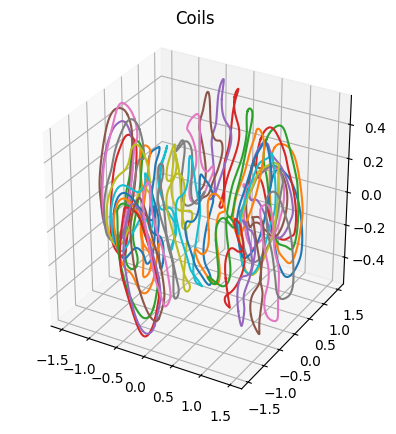

R (m)      | B_R        | B_Z        | B_phi      | Status
------------------------------------------------------------
-4.00      | -1.0612020433329483e-06 | -4.551669427528212e-06 | -1.1723414112043918e-07 | DANGER: B_phi too close to zero
-3.84      | -1.107036400361581e-06 | -4.733073268682647e-06 | -1.5909130114197658e-07 | DANGER: B_phi too close to zero
-3.67      | -1.1407907037523423e-06 | -4.917855554971958e-06 | -2.0867642256202174e-07 | DANGER: B_phi too close to zero
-3.51      | -1.1593118292780128e-06 | -5.105404267507398e-06 | -2.667947751063649e-07 | DANGER: B_phi too close to zero
-3.35      | -1.159290983832126e-06 | -5.295014911389497e-06 | -3.3420882025493466e-07 | DANGER: B_phi too close to zero
-3.18      | -1.1373737295972957e-06 | -5.4858904799484695e-06 | -4.115989884653622e-07 | DANGER: B_phi too close to zero
-3.02      | -1.0903014440006134e-06 | -5.677143768662789e-06 | -4.995178404930865e-07 | DANGER: B_phi too close to zero
-2.86      | -1.01508334413616

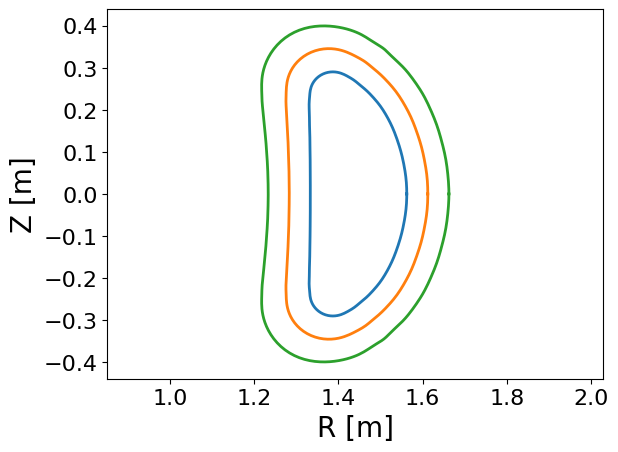

In [ ]:
# This is for ellipse 
hsx = Coil.read_makegrid("/home/yuanl/Academia/Projects/Internship_USTC/Data/FLARE_DB/HSX_Test/shared_data/coils.hsx")

# Create empty lists to gather all coordinates
x_all, y_all, z_all = [], [], []


for single_coil in hsx.data:
    x_all.extend(single_coil.x)
    y_all.extend(single_coil.y)
    z_all.extend(single_coil.z)

print("--- Coils.Ellipse 3D Domain ---")
print(f"X domain: {np.min(x_all):.3f} m to {np.max(x_all):.3f} m")
print(f"Y domain: {np.min(y_all):.3f} m to {np.max(y_all):.3f} m")
print(f"Z domain: {np.min(z_all):.3f} m to {np.max(z_all):.3f} m")


# plot
hsx.plot()
ax = plt.gca()

# 3. Force the axes to use the maximum physical domain of the ENTIRE machine
ax.set_xlim([np.min(x_all), np.max(x_all)])
ax.set_ylim([np.min(y_all), np.max(y_all)])
ax.set_zlim([np.min(z_all), np.max(z_all)])

ax.set_box_aspect([1, 1, 1])

plt.title("Coils")
plt.show()


# Finding the magnetic field 
R_test_values = np.linspace(-4, 4, 50) 

print(f"{'R (m)':<10} | {'B_R':<10} | {'B_Z':<10} | {'B_phi':<10} | Status")
print("-" * 60)

for R in R_test_values:

    B_cart = hsx.bfield([[R, 2*np.pi, 0.0]], method='bfield_HH')
    Bx, By, Bz = B_cart[0]

    Br = Bx # Bysin(phi) = 0
    Bphi = By/R # -Bxsinphi = 0) 
    
    status = "OK"
    if abs(Bphi) < 1e-3:
        status = "DANGER: B_phi too close to zero"
    elif abs(Br / Bphi) > 10 or abs(Bz / Bphi) > 10:
        status = "DANGER: Field lines escaping"
        
    print(f"{R:<10.2f} | {Br:<10} | {Bz:<10} | {Bphi:<10} | {status}")



### Boundary 1
hsx_wind1 = FourSurf.read_winding_surfce("/home/yuanl/Academia/Projects/Internship_USTC/Data/FLARE_DB/HSX_Test/shared_data/nescin_sep_0.05")
hsx_wind1.plot()
### Boundary 2 
hsx_wind2 = FourSurf.read_winding_surfce("/home/yuanl/Academia/Projects/Internship_USTC/Data/FLARE_DB/HSX_Test/shared_data/nescin_sep_0.10")
hsx_wind2.plot()
### Boundary 3 
hsx_wind3 = FourSurf.read_winding_surfce("/home/yuanl/Academia/Projects/Internship_USTC/Data/FLARE_DB/HSX_Test/shared_data/nescin_sep_0.15")
hsx_wind3.plot()

Begin field-line tracing: 
Progress |████████████████████████████████████████████████████████████| 100.0% Complete


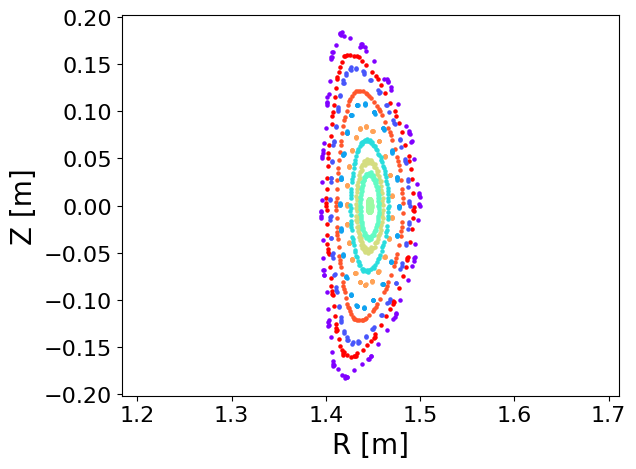

In [ ]:
def fieldline_trace(coil_data, r0, z0, phi0 = 0.0, nturns = 100, nfp = 1, nstep = 1, **kwargs): 


    # Converting from Cylindrical to Cartesian and Vice Versa 

    # Given p = (R, phi, Z)
    # x = Rcos(phi) 
    # y = Rsin(phi) 
    # z = Z 

    # Using coilpy's bfield to acquire B(Bx, By, Bz)

    # Rhat (in cartesian coordinates) = (cosphi, sinphi, 0)
    # phihat (in cartesian coordinates) = (-sinphi, cosphi, 0) 
    # Br = B dot Rhat 
    # Bphi = B dot phihat 
    # BZ = Bz

    """ 
    Need to implement direction here 
    
    """
    from scipy.integrate import solve_ivp

    # 1. Define the system of DEs (in cylindrical coordinates) 
    def fieldline(phi, F0, coil_data): 
        """
        Calculates dR/dphi and dZ/dphi for field line tracing.
        """

        point = np.array([F0[0], phi, F0[1]]) # was this a list before? 
        cosphi = np.cos(phi)
        sinphi = np.sin(phi) 

        cart = np.array([point[0]*cosphi, point[0]*sinphi, point[2]])
        B_cart = coil_data.bfield(cart, method = 'bfield_HH')
        Bx, By, Bz = B_cart[0]

        Br = Bx*cosphi + By*sinphi  
        Bphi = -Bx*sinphi + By*cosphi
        BZ = Bz 

        if Bphi == 0:
            raise ValueError(f"B_phi is zero at phi={phi}, R={point[0]}, Z={point[2]}. Cannot advance field line.")

        dRdphi = point[0]*(Br/Bphi)
        dZdphi = point[0]*(BZ/Bphi)

        return [dRdphi, dZdphi]

    # Settings
    print("Begin field-line tracing: ")
    if kwargs.get("method") is None:
        kwargs.update({"method": "RK45"})  # using RK45/LSDOA
    if kwargs.get("rtol") is None:
        kwargs.update({"rtol": 1e-6})  # minimum tolerance


    # Traces 
    dphi = 2*np.pi/nfp/nstep # 2*np.pi/nfp is the angle at which physics change before resetting, and this divided by nstep is the steps per period
    phi = phi0 + dphi*nstep * np.arange(nturns)
    
    nlines = len(r0) #Nested surfaces 
    lines = [] 

    ''' 
    nstep is only there to make sure the solver can take intermediate steps to keep the math accurate
    The physics is in nturns and nfp. Nfp makes sure that we only use the solver within the range of angles where the physics does not repeat
    Nturns and the update on the phi_start ensures that we are tracing magnetic field lines all around the stellarator. 
    For instance, in 1 turn it might go from 0 - 90, then update phi to 90 - 180 on the 2nd turn, and so on. 
    We update F to make sure that in the next turn, the solver starts from the path where the previous turn ended
    If phi is not udpated, we are left with a pie slice or a chunk of the donut 
    If F is not updated, we are left with disconnected segments that go all the way around 
    '''  
    for i in range(nlines): # looping over each starting radius 
        points = [[r0[i], z0[i]]]
        for j in range(nturns): #loop over each toroidal iteration i.e. turns 
            print_progress(i*nturns + j + 1, nlines*nturns)  # Shows progress and divides the current turn by the total amount of turns
            F = points[j] # Define the current point 
            phi_start = phi[j] #should be equal to phi_0? 
            for k in range (nstep): # loop inside one iteration 
                sol = solve_ivp(
                    fun = fieldline,
                    t_span = (phi_start, phi_start + dphi),
                    y0 = F,
                    args = (coil_data,),
                    **kwargs
                    )
                F = sol.y[:, -1] #Redefine the point 
                phi_start += dphi 
            points.append(F) # Actual lines 
        lines.append(np.array(points)) 
    return np.array(lines)




#########################


r0 = np.linspace(1.4, 1.5, 10)
z0 = np.zeros(len(r0))
hsx_field = fieldline_trace(hsx, r0, z0)
poincare_plot(hsx_field, s = 5)
plt.show()